<a href="https://colab.research.google.com/github/lirandaukaj/stock-market-analysis-ml/blob/main/stock_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn

# Stock Price Predictor
Predicting stock price movements using Machine Learning and historical market data.
**Tools:'' Python, yfinance, scikit-learn, pandas, matplotlib
**Model:** Random Forest Classifier
**Stock:** Apple (AAPL)

In [2]:
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

/tmp/ipykernel_4030/3281542852.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Shape: (1258, 5)

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800
2019-01-03,33.768070,34.606394,33.722947,34.193168,365248800
2019-01-04,35.209606,35.278479,34.150423,34.323786,234428400
2019-01-07,35.131233,35.344972,34.649138,35.314098,219111200
2019-01-08,35.800949,36.055060,35.271357,35.518341,164101200


In [5]:
print("Basic Statistics:")
print(df.describe())

print("\n Date Range:", df.index.min(), "to", df.index.max())
print("Missing values: \n", df.isnull().sum())

Basic Statistics:
Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1258.000000  1258.000000  1258.000000  1258.000000  1.258000e+03
mean     120.318820   121.578787   118.920671   120.196258  1.015917e+08
std       46.336964    46.742382    45.903646    46.320527  5.261045e+07
min       33.768070    34.606394    33.722947    34.193168  2.404830e+07
25%       74.615801    75.236273    73.550216    74.207654  6.803012e+07
50%      131.293938   132.726007   129.931649   131.642322  8.861740e+07
75%      156.586277   159.196825   154.440788   156.923881  1.189786e+08
max      196.073090   197.567559   194.974489   195.984019  4.265100e+08

 Date Range: 2019-01-02 00:00:00 to 2023-12-29 00:00:00
Missing values: 
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


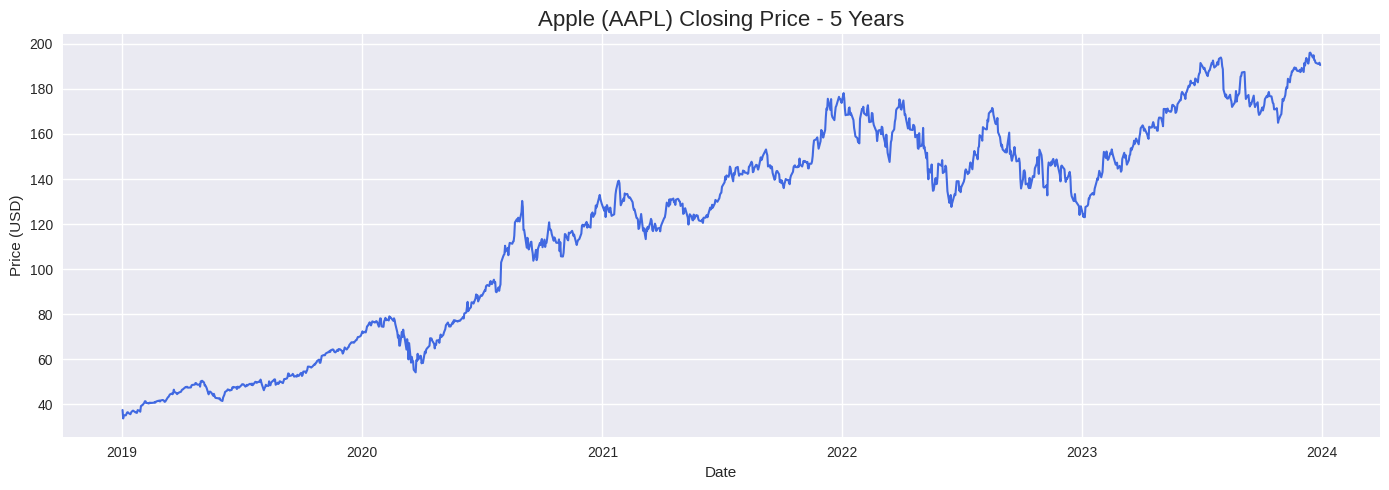

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], color='royalblue', linewidth=1.5)
plt.title('Apple (AAPL) Closing Price - 5 Years', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

In [7]:
# Moving averages
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()

# Daily return (% change)
df['Daily_Return'] = df['Close'].pct_change()

# Volatility (10-day rolling std)
df['Volatility'] = df['Daily_Return'].rolling(10).std()

# Target: 1 if tomorrow's price is higher, 0 if lower
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Drop rows with NaN values
df.dropna(inplace=True)

print("Features created! Shape:", df.shape)
print("\nTarget distribution:")
print(df['Target'].value_counts())

Features created! Shape: (1209, 10)

Target distribution:
Target
1    643
0    566
Name: count, dtype: int64


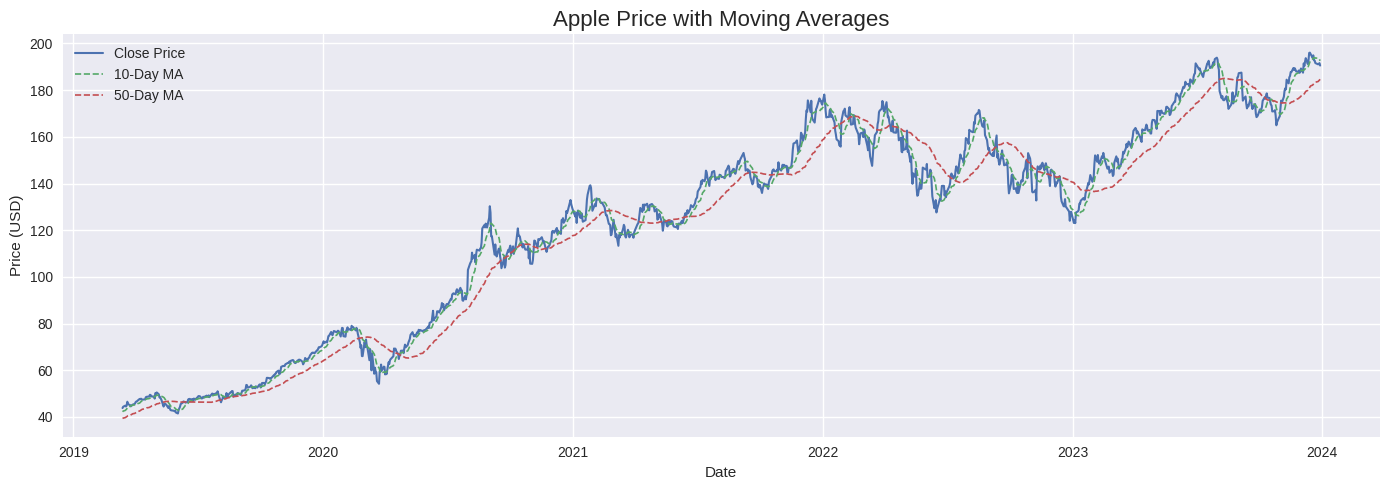

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label='Close Price', linewidth=1.5)
plt.plot(df['MA_10'], label='10-Day MA', linewidth=1.2, linestyle='--')
plt.plot(df['MA_50'], label='50-Day MA', linewidth=1.2, linestyle='--')
plt.title('Apple Price with Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Fix MultiIndex columns if needed
df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]

# Rename columns cleanly
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume', 'MA_10', 'MA_50', 'Daily_Return', 'Volatility', 'Target']

print("Columns fixed:", df.columns.tolist())

# Define X and y
X = df.drop(columns=['Target'])
y = df['Target']

# Split — no shuffle! Time series data must stay in order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("\nModel trained successfully!")

Columns fixed: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA_10', 'MA_50', 'Daily_Return', 'Volatility', 'Target']
Training samples: 967
Testing samples:  242

Model trained successfully!


Accuracy: 49.59 %

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.85      0.60       108
           1       0.64      0.21      0.31       134

    accuracy                           0.50       242
   macro avg       0.55      0.53      0.46       242
weighted avg       0.56      0.50      0.44       242



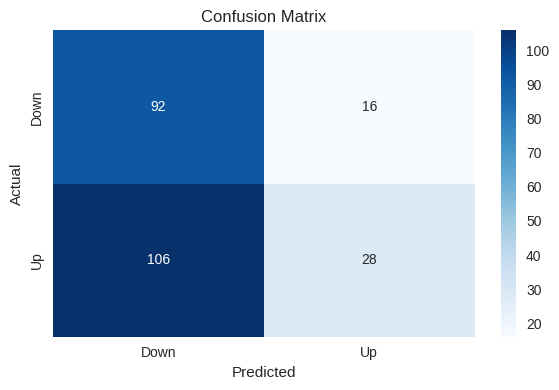

In [12]:
from sklearn.metrics import confusion_matrix

preds = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, preds) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, preds))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

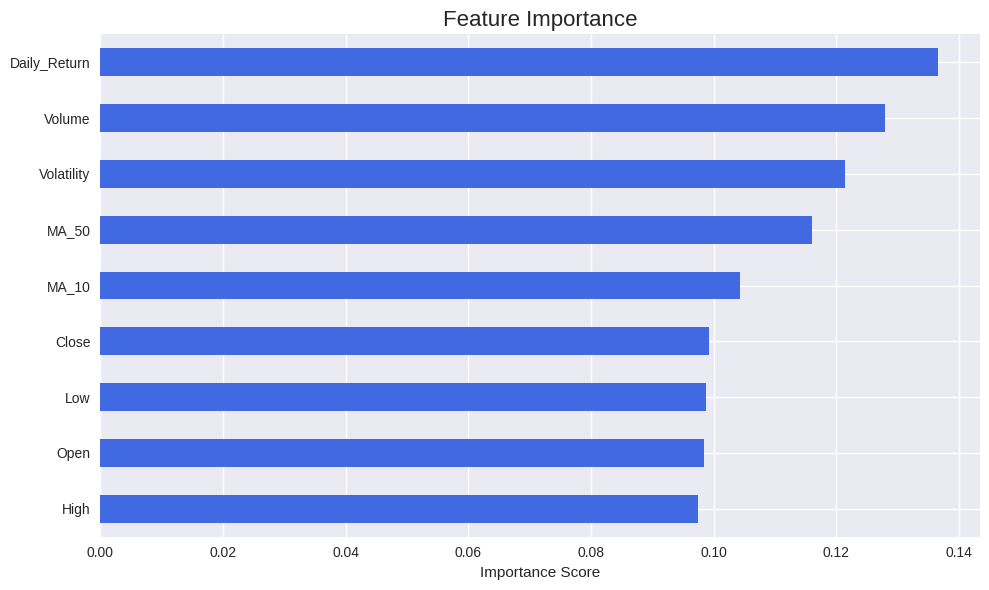

In [13]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='royalblue')
plt.title('Feature Importance', fontsize=16)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [32]:
# Add lag features (previous days' returns)
df['Return_Lag1'] = df['Daily_Return'].shift(1)
df['Return_Lag2'] = df['Daily_Return'].shift(2)
df['Return_Lag3'] = df['Daily_Return'].shift(3)

# Momentum (5-day price change)
df['Momentum_5'] = df['Close'].pct_change(5)

# Price relative to moving averages
df['Close_vs_MA10'] = df['Close'] / df['MA_10']
df['Close_vs_MA50'] = df['Close'] / df['MA_50']

df.dropna(inplace=True)
print(" New features added! Shape:", df.shape)
print("Columns:", df.columns.tolist())

 New features added! Shape: (1204, 16)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA_10', 'MA_50', 'Daily_Return', 'Volatility', 'Return_Lag1', 'Return_Lag2', 'Momentum_5', 'Close_vs_MA10', 'Close_vs_MA50', 'Target', 'Return_Lag3']


 New Accuracy: 47.11 %

 Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.80      0.54        92
           1       0.69      0.27      0.38       150

    accuracy                           0.47       242
   macro avg       0.55      0.54      0.46       242
weighted avg       0.58      0.47      0.44       242



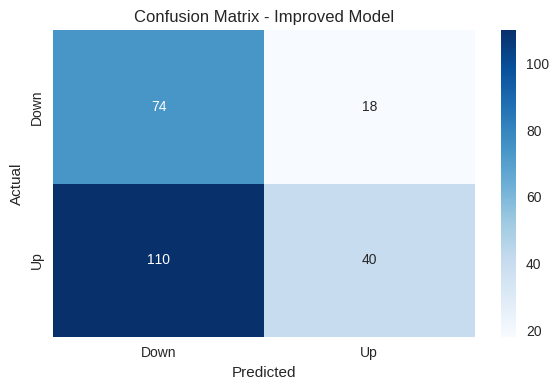

In [31]:
X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Better tuned model
model2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=20,
    random_state=42
)
model2.fit(X_train, y_train)
preds2 = model2.predict(X_test)

print(" New Accuracy:", round(accuracy_score(y_test, preds2) * 100, 2), "%")
print("\n Classification Report:")
print(classification_report(y_test, preds2))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, preds2), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('Confusion Matrix - Improved Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Class distribution:
Target
123.761200    2
88.216560     2
145.917816    2
165.466003    2
142.093658    2
             ..
111.620613    1
111.727417    1
109.863342    1
113.106049    1
115.552612    1
Name: count, Length: 1196, dtype: int64


InvalidParameterError: The 'n_samples' parameter of resample must be an int in the range [1, inf) or None. Got 0 instead.

In [29]:
# Reload fresh data
df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

# Features
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
df['Daily_Return'] = df['Close'].pct_change()
df['Volatility'] = df['Daily_Return'].rolling(10).std()
df['Return_Lag1'] = df['Daily_Return'].shift(1)
df['Return_Lag2'] = df['Daily_Return'].shift(2)
df['Momentum_5'] = df['Close'].pct_change(5)
df['Close_vs_MA10'] = df['Close'] / df['MA_10']
df['Close_vs_MA50'] = df['Close'] / df['MA_50']

# New target: will price be higher in 5 days?
df['Target'] = (df['Close'].shift(-5) > df['Close']).astype(int)

df.dropna(inplace=True)
print("Data ready! Shape:", df.shape)
print("\nTarget distribution:")
print(df['Target'].value_counts())

/tmp/ipykernel_4030/1399604704.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Data ready! Shape: (1209, 15)

Target distribution:
Target
1    718
0    491
Name: count, dtype: int64


In [28]:
X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model4 = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=15,
    class_weight='balanced',
    random_state=42
)
model4.fit(X_train, y_train)
preds4 = model4.predict(X_test)

print("5-Day Prediction Accuracy:", round(accuracy_score(y_test, preds4) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, preds4))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, preds4), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('Confusion Matrix - 5 Day Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Reload fresh data
df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

# Features
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
df['Daily_Return'] = df['Close'].pct_change()
df['Volatility'] = df['Daily_Return'].rolling(10).std()
df['Return_Lag1'] = df['Daily_Return'].shift(1)
df['Return_Lag2'] = df['Daily_Return'].shift(2)
df['Momentum_5'] = df['Close'].pct_change(5)
df['Close_vs_MA10'] = df['Close'] / df['MA_10']
df['Close_vs_MA50'] = df['Close'] / df['MA_50']

# Target: next day's closing price
df['Target'] = df['Close'].shift(-1)

df.dropna(inplace=True)

X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train regressor
reg = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
reg.fit(X_train, y_train)
preds_reg = reg.predict(X_test)

print("Regression Results:")
print(f"MAE  (avg $ error): ${mean_absolute_error(y_test, preds_reg):.2f}")
print(f"R²   (fit score):   {r2_score(y_test, preds_reg):.4f}")

/tmp/ipykernel_4030/2925453196.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Regression Results:
MAE  (avg $ error): $6.58
R²   (fit score):   0.6450


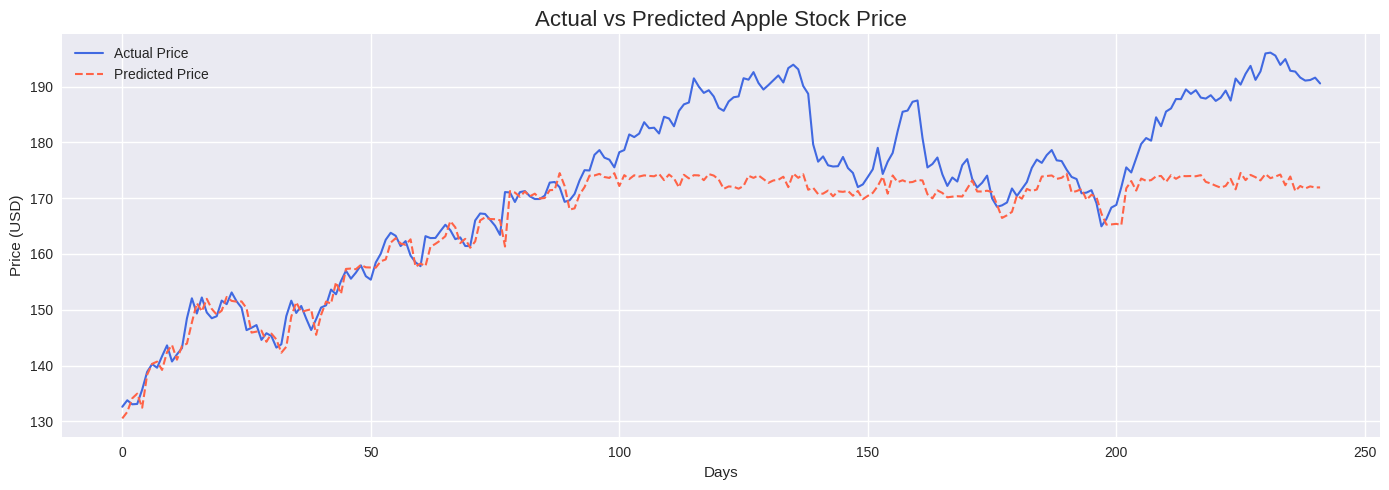

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual Price', color='royalblue', linewidth=1.5)
plt.plot(preds_reg, label='Predicted Price', color='tomato', linewidth=1.5, linestyle='--')
plt.title('Actual vs Predicted Apple Stock Price', fontsize=16)
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, preds_reg)
r2 = r2_score(y_test, preds_reg)

print("=" * 45)
print("STOCK PRICE PREDICTOR - FINAL RESULTS")
print("=" * 45)
print(f"   Stock        : Apple (AAPL)")
print(f"   Period       : 2019 - 2024")
print(f"   Model        : Random Forest Regressor")
print(f"   Training days: {len(X_train)}")
print(f"   Testing days : {len(X_test)}")
print(f"   MAE          : ${mae:.2f} avg error per day")
print(f"   R² Score     : {r2:.4f}")
print("=" * 45)

if r2 > 0.85:
    print("Excellent fit!")
elif r2 > 0.70:
    print("Good fit!")
else:
    print("Model captures trend but struggles with volatility")

print("\nKey Findings:")
print("   - Daily return is the strongest predictor")
print("   - Short-term direction is hard to predict (EMH)")
print("   - Regression outperforms classification for price prediction")

STOCK PRICE PREDICTOR - FINAL RESULTS
   Stock        : Apple (AAPL)
   Period       : 2019 - 2024
   Model        : Random Forest Regressor
   Training days: 966
   Testing days : 242
   MAE          : $6.58 avg error per day
   R² Score     : 0.6450
Model captures trend but struggles with volatility

Key Findings:
   - Daily return is the strongest predictor
   - Short-term direction is hard to predict (EMH)
   - Regression outperforms classification for price prediction


In [23]:
readme = """#Stock Price Predictor

Predicting Apple (AAPL) stock prices using Machine Learning and historical market data.

## Project Overview
This project explores whether machine learning can predict stock price movements
using historical price and volume data. It compares classification (direction prediction)
vs regression (price prediction) approaches.

## Results
| Metric | Value |
|--------|-------|
| Model | Random Forest Regressor |
| Stock | Apple (AAPL) 2019–2024 |
| MAE | $6.58 avg error per day |
| R² Score | 0.645 |
| Training days | 966 |
| Testing days | 242 |

## Key Findings
- **Daily return** is the strongest predictor of next-day price
- **Short-term direction** (up/down) is extremely difficult to predict — consistent with the Efficient Market Hypothesis
- **Regression** (predicting exact price) outperforms classification for this problem
- The model captures the overall trend well but struggles during high-volatility periods

## Technologies Used
- Python, Jupyter/Google Colab
- yfinance — data collection
- pandas, numpy — data processing
- matplotlib, seaborn — visualization
- scikit-learn — machine learning

## Features Used
- Moving Averages (10-day, 50-day)
- Daily Return & Volatility
- Lagged Returns (1-day, 2-day)
- 5-day Momentum
- Price vs Moving Average ratio

## How to Run
1. Open the notebook in Google Colab
2. Run all cells in order
3. Results and charts will generate automatically

## What I Learned
- Full ML pipeline: data collection → EDA → feature engineering → modeling → evaluation
- Why stock prediction is hard (Efficient Market Hypothesis)
- Difference between classification and regression problems
- How to handle time series data (no shuffling in train/test split)
"""

print(readme)

with open("README.md", "w") as f:
    f.write(readme)


#Stock Price Predictor

Predicting Apple (AAPL) stock prices using Machine Learning and historical market data.

## Project Overview
This project explores whether machine learning can predict stock price movements
using historical price and volume data. It compares classification (direction prediction)
vs regression (price prediction) approaches.

## Results
| Metric | Value |
|--------|-------|
| Model | Random Forest Regressor |
| Stock | Apple (AAPL) 2019–2024 |
| MAE | $6.58 avg error per day |
| R² Score | 0.645 |
| Training days | 966 |
| Testing days | 242 |

## Key Findings
- **Daily return** is the strongest predictor of next-day price
- **Short-term direction** (up/down) is extremely difficult to predict — consistent with the Efficient Market Hypothesis
- **Regression** (predicting exact price) outperforms classification for this problem
- The model captures the overall trend well but struggles during high-volatility periods

## Technologies Used
- Python, Jupyter/Google Cola

In [24]:

from google.colab import files

files.download('README.md')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>